**Problem Description: Dynamic Pricing as a Non-Stationary Multi-Armed Bandits**

The seller has a set of discrete price options $\{p_1, p_2, p_3, p_4\}$, e.g., $\{5, 10, 15, 20\}$ currency units. The probability of a customer purchasing the product at each price varies over time. The goal is to maximize revenue (or minimize regret) by adaptively choosing prices based on observed purchases. Below we simulate this situation.

You will have to implement and test two algorithms for the non-stationary multi-armed bandit problem DiscountedUCB and SlidingWindowUCB from the paper [On Upper-Confidence Bound Policies for Non-Stationary Bandit Problems](https://arxiv.org/pdf/0805.3415) by Garivier and Moulines.

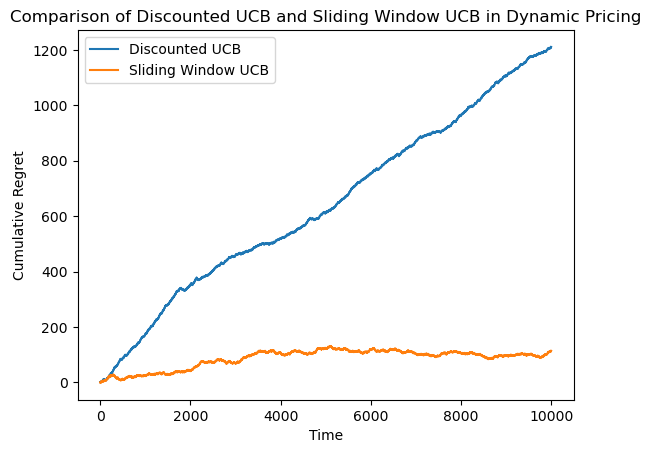

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class DynamicPricingEnv:
    def __init__(self, prices, change_points, reward_probabilities):
        self.prices = prices
        self.change_points = change_points
        self.reward_probabilities = reward_probabilities
        self.current_phase = 0
        self.t = 0

    def step(self, price_index):
        if self.t in self.change_points:
            self.current_phase = min(self.current_phase + 1, len(self.reward_probabilities) - 1)
        self.t += 1
        return np.random.rand() < self.reward_probabilities[self.current_phase][price_index]

    def reset(self):
        self.current_phase = 0
        self.t = 0

import numpy as np

class DiscountedUCB:
    def __init__(self, n_arms, gamma=0.99):
        self.n_arms = n_arms
        self.gamma = gamma  # Discount factor
        self.counts = np.zeros(n_arms)  # Number of times each arm was pulled
        self.values = np.zeros(n_arms)  # Estimated values for each arm
        self.t = 0  # Total number of trials
        # For discounted UCB, we need to track discounted sum of rewards and counts
        self.discounted_rewards = np.zeros(n_arms)
        self.discounted_counts = np.zeros(n_arms)
    
    def select_arm(self):
        # Ensure all arms are tried at least once
        if np.min(self.counts) == 0:
            return np.argmin(self.counts)
        
        # Calculate the discounted UCB for each arm
        ucb_values = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # Calculate the average reward (discounted)
            if self.discounted_counts[arm] > 0:
                mean_reward = self.discounted_rewards[arm] / self.discounted_counts[arm]
            else:
                mean_reward = 0
            
            # Calculate exploration bonus with log of discounted counts
            exploration = np.sqrt((2 * np.log(np.sum(self.discounted_counts))) / self.discounted_counts[arm])
            
            # UCB value is mean reward plus exploration bonus
            ucb_values[arm] = mean_reward + exploration
        
        # Return the arm with the highest UCB value
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        # Increment time step
        self.t += 1
        
        # Update traditional counts
        self.counts[arm] += 1
        
        # Apply discount factor to all discounted counts and rewards
        self.discounted_counts *= self.gamma
        self.discounted_rewards *= self.gamma
        
        # Update the discounted count and reward for the selected arm
        self.discounted_counts[arm] += 1
        self.discounted_rewards[arm] += reward
        
        # Update the estimated value of the arm
        if self.discounted_counts[arm] > 0:
            self.values[arm] = self.discounted_rewards[arm] / self.discounted_counts[arm]


class SlidingWindowUCB:
    def __init__(self, n_arms, window_size=50):   # Default window size set to 50
        self.n_arms = n_arms
        self.window_size = window_size
        self.rewards = [[] for _ in range(n_arms)]
        self.t = 0  # Total number of trials
    
    def select_arm(self):
        # Ensure all arms are tried at least once
        for arm in range(self.n_arms):
            if len(self.rewards[arm]) == 0:
                return arm
        
        # Calculate the UCB for each arm using only the rewards within the sliding window
        ucb_values = np.zeros(self.n_arms)
        
        for arm in range(self.n_arms):
            # Calculate the mean reward within the window
            if len(self.rewards[arm]) > 0:
                mean_reward = np.mean(self.rewards[arm])
            else:
                mean_reward = 0
            
            # Calculate exploration bonus using the window size for normalization
            n_samples = len(self.rewards[arm])
            exploration = np.sqrt((2 * np.log(self.t)) / n_samples)
            
            # UCB value is mean reward plus exploration bonus
            ucb_values[arm] = mean_reward + exploration
        
        # Return the arm with the highest UCB value
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        # Increment time step
        self.t += 1
        
        # Add the new reward to the selected arm's history
        self.rewards[arm].append(reward)
        
        # Keep only the most recent window_size rewards
        if len(self.rewards[arm]) > self.window_size:
            self.rewards[arm].pop(0)  # Remove the oldest reward
# Experiment Setup
prices = [5, 10, 15, 20]
change_points = [2000, 4000, 6000, 8000]
reward_probabilities = [
    [0.3, 0.5, 0.2, 0.1],  # Phase 1
    [0.2, 0.6, 0.3, 0.15], # Phase 2
    [0.1, 0.4, 0.5, 0.3],  # Phase 3
    [0.25, 0.35, 0.3, 0.2], # Phase 4
    [0.15, 0.5, 0.25, 0.4]  # Phase 5
]

env = DynamicPricingEnv(prices, change_points, reward_probabilities)
d_ucb = DiscountedUCB(len(prices))
sw_ucb = SlidingWindowUCB(len(prices))

T = 10000  # Total time steps
regrets_d = []
regrets_sw = []

for t in range(T):
    # Discounted UCB
    arm_d = d_ucb.select_arm()
    reward_d = env.step(arm_d)
    d_ucb.update(arm_d, reward_d)
    regrets_d.append(max(reward_probabilities[env.current_phase]) - reward_d)

    # Sliding Window UCB
    arm_sw = sw_ucb.select_arm()
    reward_sw = env.step(arm_sw)
    sw_ucb.update(arm_sw, reward_sw)
    regrets_sw.append(max(reward_probabilities[env.current_phase]) - reward_sw)

# Plot Regrets
plt.plot(np.cumsum(regrets_d), label='Discounted UCB')
plt.plot(np.cumsum(regrets_sw), label='Sliding Window UCB')
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.legend()
plt.title("Comparison of Discounted UCB and Sliding Window UCB in Dynamic Pricing")
plt.show()
